In [1]:
from sqlalchemy import create_engine
import pandas as pd 

engine = create_engine(
    'snowflake://{user}:{password}@{account}/{database}/{schema}?warehouse={warehouse}&role={role}'.format(
        user="lujymeg",
        password='Lamlamlam31*31*',
        account='SIOROVO-WYB67513',
        warehouse='COMPUTE_WH',
        database='WALMART',
        schema='PUBLIC_BRONZE',
        role='ACCOUNTADMIN'
    )
)
query = """
select * from WALMART.PUBLIC_GOLD.WALMART_JOINED_REDUCED; 
"""

df = pd.read_sql(query, engine)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572887 entries, 0 to 4572886
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   store_id            int64  
 1   dept_id             int64  
 2   store_weekly_sales  float64
 3   store_date          object 
 4   fuel_price          float64
 5   store_temperature   float64
 6   unemployment        int64  
 7   cpi                 int64  
 8   markdown1           float64
 9   markdown2           float64
 10  markdown3           float64
 11  markdown4           float64
 12  markdown5           float64
 13  store_type          object 
 14  store_size          int64  
 15  isholiday           bool   
dtypes: bool(1), float64(8), int64(5), object(2)
memory usage: 527.7+ MB
None


Index([False, True], dtype='bool', name='isholiday')


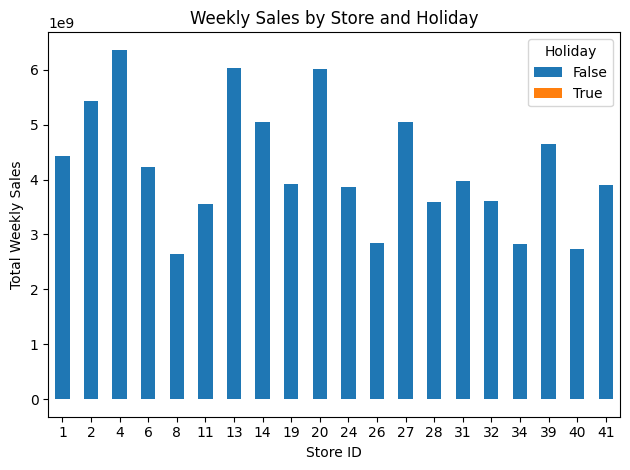

isholiday
False    4545915
True       26972
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
import pandas as pd


# Make sure 'store_weekly_sales' is numeric
df['store_weekly_sales'] = pd.to_numeric(df['store_weekly_sales'], errors='coerce')

# Aggregate weekly sales by store and holiday
sales_summary = df.groupby(['store_id', 'isholiday'])['store_weekly_sales'].sum().unstack(fill_value=0)
# print(sales_summary)

# Plot stacked bar chart
sales_summary.plot(kind='bar', stacked=True)

plt.title('Weekly Sales by Store and Holiday')

plt.xlabel('Store ID')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=0)
plt.legend(title='Holiday')

plt.tight_layout()
plt.show()

print(df['isholiday'].value_counts())


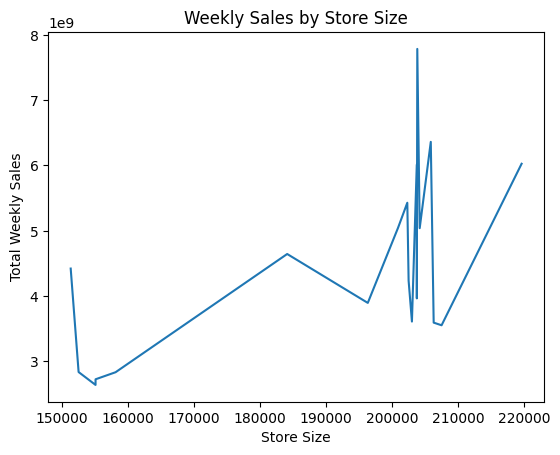

In [24]:


sales_store_size = df.groupby(['store_size'])['store_weekly_sales'].sum()

sales_store_month.plot(kind='line')

plt.title('Weekly Sales by Store Size')

plt.xlabel('Store Size')
plt.ylabel('Total Weekly Sales')
plt.show()

store_type  store_date_month
A           April              -5.706086e+05
            August              1.530034e+05
            December            4.968743e+06
            February            3.501871e+06
            January             2.539348e+06
            July                8.302427e+05
            June                2.439728e+06
            March               1.141372e+06
            May                 8.949960e+05
            November            3.644954e+06
            October             8.463932e+10
            September          -3.896414e+04
Name: store_weekly_sales, dtype: float64


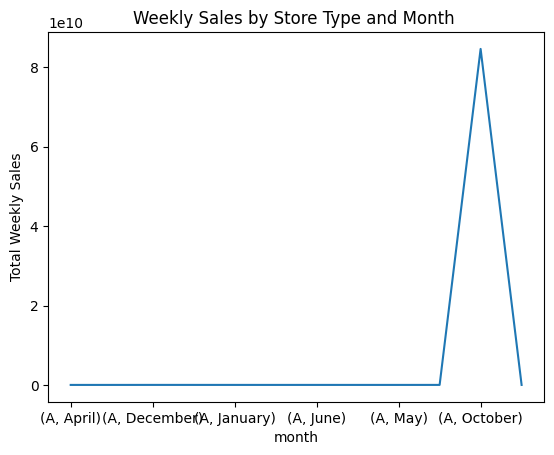

In [22]:

df['store_date_month'] = df['store_date'].dt.month_name()
sales_store_month = df.groupby(['store_type', 'store_date_month'])['store_weekly_sales'].sum()

print(sales_store_month)


sales_store_month.plot(kind='line')

plt.title('Weekly Sales by Store Type and Month ')

plt.xlabel('month')
plt.ylabel('Total Weekly Sales')
plt.show()


/var/folders/y5/gckmtw2d341f_6vd7jhbx6140000gn/T/ipykernel_41355/161364912.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['year', 'temp_bin'])['store_weekly_sales']


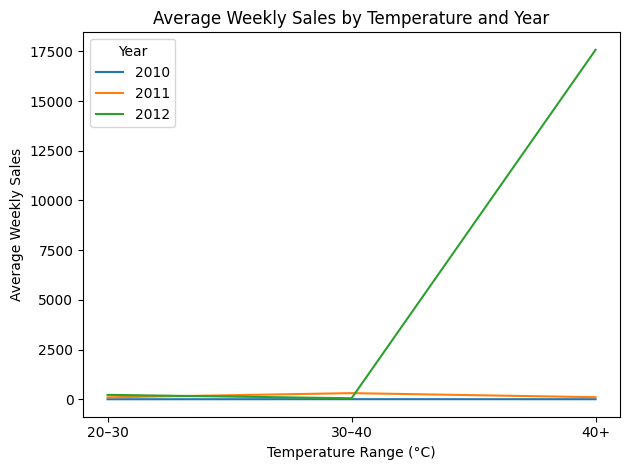

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure correct dtypes
df['store_date'] = pd.to_datetime(df['store_date'])
df['store_weekly_sales'] = pd.to_numeric(df['store_weekly_sales'], errors='coerce')
df['store_temperature'] = pd.to_numeric(df['store_temperature'], errors='coerce')

# Extract year
df['year'] = df['store_date'].dt.year
temp_bins = [-10, 0, 10, 20, 30, 40, 50]
temp_labels = ['<0', '0–10', '10–20', '20–30', '30–40', '40+']

df['temp_bin'] = pd.cut(
    df['store_temperature'],
    bins=temp_bins,
    labels=temp_labels,
    include_lowest=True
)
sales_temp_year = (
    df.groupby(['year', 'temp_bin'])['store_weekly_sales']
      .mean()   # mean weekly sales is more meaningful than sum
      .reset_index()
      
)

plt.figure()
for year in sales_temp_year['year'].unique():
    subset = sales_temp_year[sales_temp_year['year'] == year]
    plt.plot(subset['temp_bin'], subset['store_weekly_sales'], label=year)

plt.title('Average Weekly Sales by Temperature and Year')
plt.xlabel('Temperature Range (°C)')
plt.ylabel('Average Weekly Sales')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

